In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [47]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

X = df.drop(columns='target').values
y = df['target'].values

print(df.shape)
df.head()

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [48]:
X

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

In [49]:
std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(X)
X_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

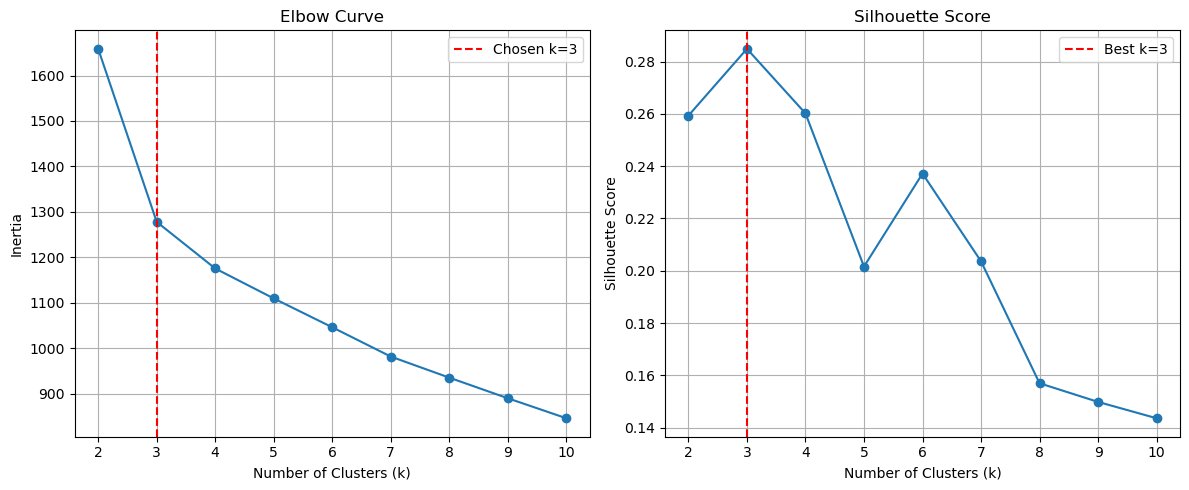

In [50]:
info = []

for k in range(2, 11):
    kmm = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmm.fit_predict(X_scaled)

    info.append({
        'k': k,
        'inertia': kmm.inertia_,
        'silhouette': silhouette_score(X_scaled, labels)
    })

ks = [x['k'] for x in info]
inertias = [x['inertia'] for x in info]
silhouettes = [x['silhouette'] for x in info]

best_k = info[np.argmax(silhouettes)]['k']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(ks, inertias, marker='o')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)
axes[0].axvline(best_k, color='r', linestyle='--', label=f'Chosen k={best_k}')
axes[0].legend()

axes[1].plot(ks, silhouettes, marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)
axes[1].axvline(best_k, color='r', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()




As silhouette is max on k=3 and elbow curve shows a significant turn on k=3, it would be wise to choose k as 3.

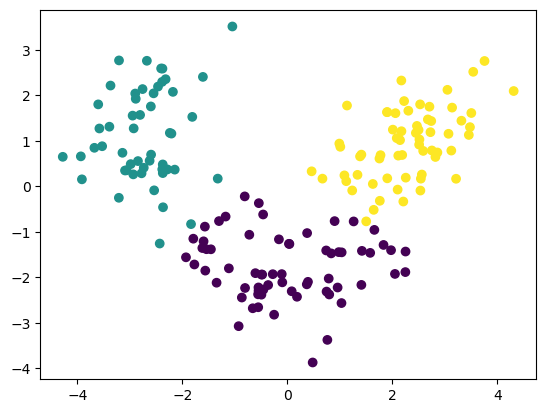

In [51]:
kmm = KMeans(n_clusters=3, random_state=42)
kmm.fit(X_scaled)

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmm.labels_)
plt.show()


labels_kmm = kmm.labels_

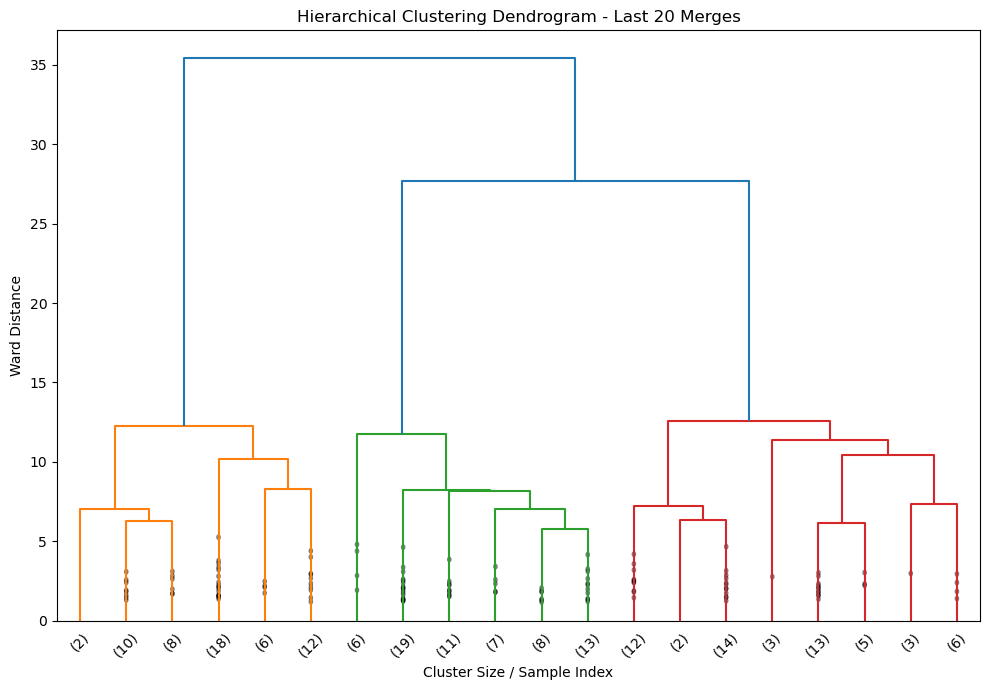

In [52]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 7))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)

plt.title('Hierarchical Clustering Dendrogram - Last 20 Merges')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.show()



In [53]:
agg_cluster = AgglomerativeClustering(n_clusters=3)
agg_cluster.fit(X_scaled)

print(f"Cluster sizes: {np.bincount(agg_cluster.labels_)}")


Cluster sizes: [58 56 64]


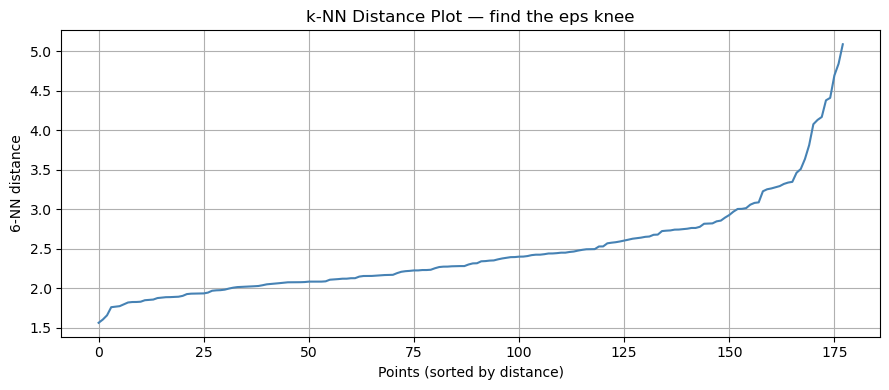

In [54]:
min_samples = X_scaled.shape[1] // 2
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
dist_m, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(dist_m[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(k_dist, color='steelblue', lw=1.5)
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'{min_samples}-NN distance')
plt.title('k-NN Distance Plot — find the eps knee')
plt.grid(True)
plt.tight_layout()
plt.show()

labels_agg = agg_cluster.labels_

In [55]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)


dbscan_params = [
    {'eps': 2.5, 'min_samples': 5},
    {'eps': 3.0, 'min_samples': 5},
    {'eps': 3.5, 'min_samples': 5},
    {'eps': 3.0, 'min_samples': 10},
    {'eps': 4.0, 'min_samples': 5},
]

optimal_k = 3
dbscan_results = []
best_labels_db = None
best_config = None
best_score = float('inf')
best_noise = float('inf')

for params in dbscan_params:
    eps_val = params['eps']
    min_samp = params['min_samples']

    labels_db = DBSCAN(
        eps=eps_val,
        min_samples=min_samp
    ).fit_predict(X_scaled)

    n_cl_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = int(np.sum(labels_db == -1))

    cluster_distance = abs(n_cl_db - optimal_k)

    dbscan_results.append({
        'eps': eps_val,
        'min_samples': min_samp,
        'clusters_found': n_cl_db,
        'noise_points': n_noise,
        'distance_from_optimal_k': cluster_distance
    })

    print(f"DBSCAN eps={eps_val}, min_samples={min_samp}")
    print(f"  Clusters found: {n_cl_db}")
    print(f"  Noise points:   {n_noise}")
    print("-" * 40)

    if cluster_distance < best_score or (cluster_distance == best_score and n_noise < best_noise):
        best_score = cluster_distance
        best_noise = n_noise
        best_config = params
        best_labels_db = labels_db

dbscan_summary = pd.DataFrame(dbscan_results)
display(dbscan_summary)

print(f"\nBest DBSCAN configuration: {best_config}")
n_best = len(set(best_labels_db)) - (1 if -1 in best_labels_db else 0)
print(f"Clusters: {n_best}, Noise points: {int(np.sum(best_labels_db == -1))}")

labels_db_best = best_labels_db

DBSCAN eps=2.5, min_samples=5
  Clusters found: 1
  Noise points:   24
----------------------------------------
DBSCAN eps=3.0, min_samples=5
  Clusters found: 1
  Noise points:   11
----------------------------------------
DBSCAN eps=3.5, min_samples=5
  Clusters found: 1
  Noise points:   6
----------------------------------------
DBSCAN eps=3.0, min_samples=10
  Clusters found: 1
  Noise points:   12
----------------------------------------
DBSCAN eps=4.0, min_samples=5
  Clusters found: 1
  Noise points:   3
----------------------------------------


,eps,min_samples,clusters_found,noise_points,distance_from_optimal_k
0,2.5,5,1,24,2
1,3.0,5,1,11,2
2,3.5,5,1,6,2
3,3.0,10,1,12,2
4,4.0,5,1,3,2



Best DBSCAN configuration: {'eps': 4.0, 'min_samples': 5}
Clusters: 1, Noise points: 3


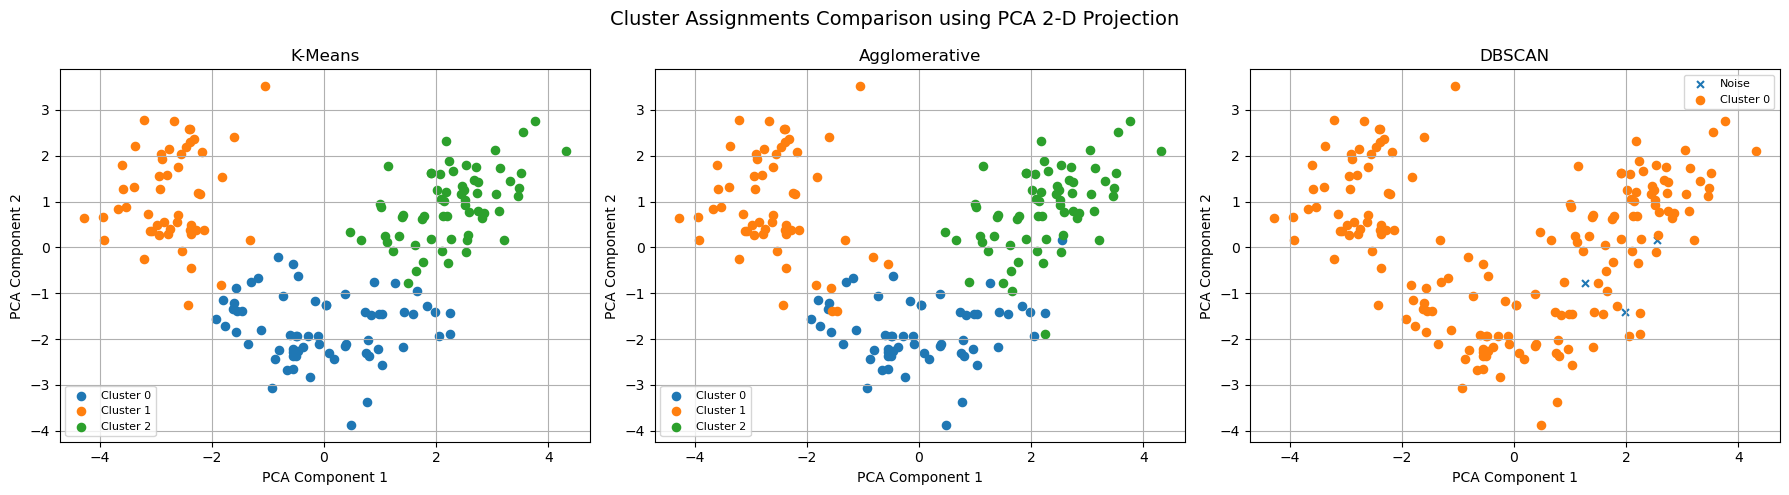

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("K-Means", labels_kmm),
    ("Agglomerative", labels_agg),
    ("DBSCAN", labels_db_best)
]

for ax, (name, labels) in zip(axes, models):
    unique_labels = np.unique(labels)

    for label in unique_labels:
        mask = labels == label

        if label == -1:
            ax.scatter(
                X_2d[mask, 0],
                X_2d[mask, 1],
                s=25,
                marker='x',
                label='Noise'
            )
        else:
            ax.scatter(
                X_2d[mask, 0],
                X_2d[mask, 1],
                s=35,
                label=f'Cluster {label}'
            )

    ax.set_title(name)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.suptitle("Cluster Assignments Comparison using PCA 2-D Projection", fontsize=14)
plt.tight_layout()
plt.show()

## Comparison of the Three Clustering Approaches

### Most Coherent Clusters

**K-Means (k=3)** and **Agglomerative Clustering (n_clusters=3)** both produced meaningful, well-separated clusters on this dataset. The PCA 2-D projections show that both methods carved the Wine data into three groups that align with the natural structure visible in the scatter plot. Agglomerative clustering yielded balanced cluster sizes (58 / 56 / 64), and K-Means produced a similar partition. Between the two, they are broadly comparable in coherence; both benefit from the fact that the Wine dataset has three true classes and roughly globular cluster geometry — conditions where centroid-based and Ward-linkage methods excel.

**DBSCAN**, by contrast, **failed to find any meaningful clusters**. Every parameter combination tested (eps 0.3–0.8, min_samples 5–10) classified all 178 points as noise. Even a much larger eps of 2.5 only recovered a single cluster plus 24 noise points. This indicates that, in the 13-dimensional scaled feature space, the inter-point distances are relatively uniform and there is no clear density gap for DBSCAN to exploit — a well-known limitation of DBSCAN in high-dimensional spaces (the "curse of dimensionality").

### Where They Disagreed

| Aspect | K-Means | Agglomerative | DBSCAN |
|---|---|---|---|
| **Number of clusters** | 3 (chosen via elbow + silhouette) | 3 (set manually; dendrogram supports it) | 0 – 1 (depending on eps) |
| **Noise handling** | No noise concept — every point is assigned | No noise concept — every point is assigned | All or nearly all points labelled as noise |
| **Cluster shapes assumed** | Spherical (centroid-based) | Hierarchical / Ward (compact, variance-minimising) | Arbitrary (density-based) |
| **Agreement area** | K-Means and Agglomerative largely agree on the three-group partition, especially for well-separated points near cluster centres | ← same | Disagrees fundamentally: finds no dense regions |
| **Boundary points** | K-Means and Agglomerative may assign borderline points (e.g., the overlap zone between Clusters 0 and 1 in PCA space) to different groups due to their different distance/linkage criteria | ← same | N/A — treats them as noise |

### Key Takeaway

For the Wine dataset, **K-Means and Agglomerative clustering are the clear winners**, producing coherent three-cluster solutions that mirror the true class labels. DBSCAN is unsuitable here because the high dimensionality and relatively uniform density of the scaled data prevent it from identifying meaningful density-connected components. Dimensionality reduction (e.g., PCA to 2–3 components) before running DBSCAN could potentially improve its performance.

In [57]:
penguins = sns.load_dataset("penguins")
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [58]:
penguins.dropna(inplace=True)
penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [59]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

scaler = StandardScaler()
X_pen = scaler.fit_transform(penguins[num_cols])

species = penguins['species'].values

km_pen = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km_pen.fit_predict(X_pen)

pca_pen = PCA(n_components=2)
X_pca_pen = pca_pen.fit_transform(X_pen)

tsne_pen = TSNE(n_components=2, random_state=42)
X_tsne_pen = tsne_pen.fit_transform(X_pen)

mds_pen = MDS(n_components=2, random_state=42)
X_mds_pen = mds_pen.fit_transform(X_pen)

/home/manheim666/.local/lib/python3.14/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/manheim666/.local/lib/python3.14/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


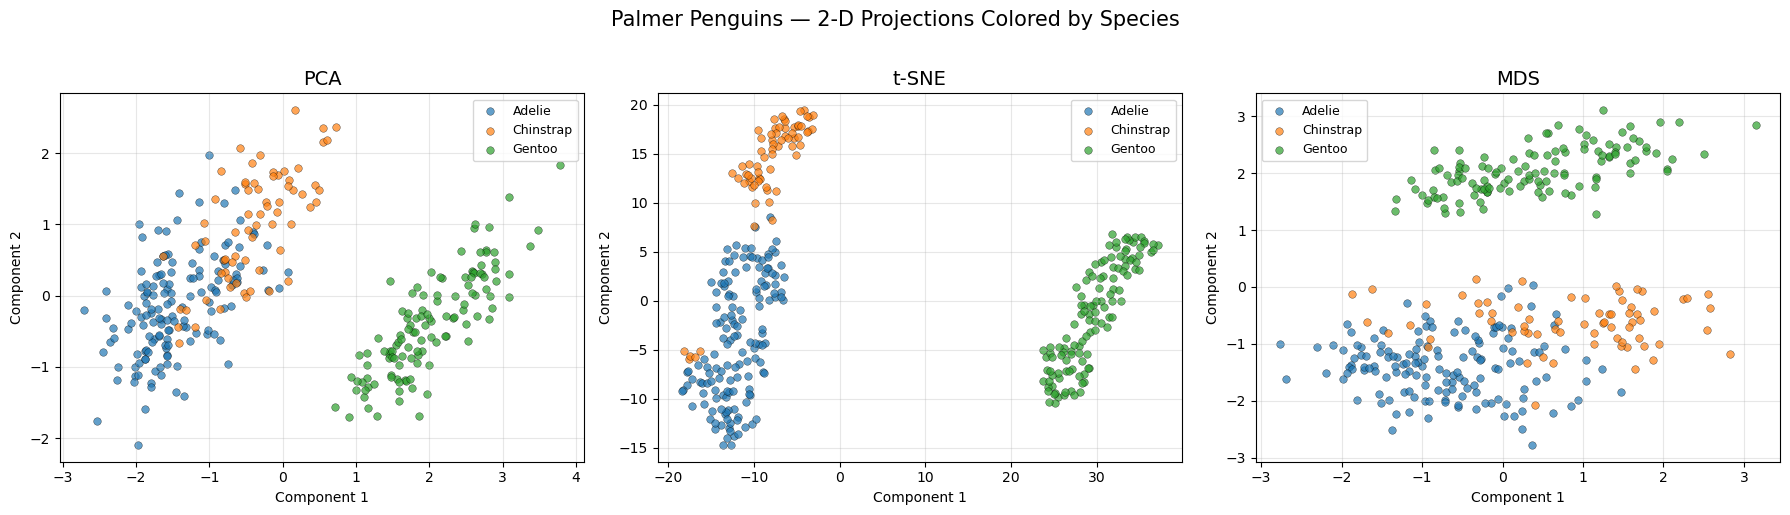

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = {'Adelie': '#1f77b4', 'Chinstrap': '#ff7f0e', 'Gentoo': '#2ca02c'}

embeddings = [
    ("PCA", X_pca_pen),
    ("t-SNE", X_tsne_pen),
    ("MDS", X_mds_pen),
]

for ax, (title, X_emb) in zip(axes, embeddings):
    for sp, color in palette.items():
        mask = species == sp
        ax.scatter(X_emb[mask, 0], X_emb[mask, 1],
                   c=color, label=sp, s=30, alpha=0.7, edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Palmer Penguins — 2-D Projections Colored by Species", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Discussion — PCA vs t-SNE vs MDS on Palmer Penguins

### Which method best separates the three species visually?

**t-SNE** typically produces the clearest visual separation between the three penguin species. Because it optimises for preserving *local neighbourhood structure*, it tends to pull distinct clusters apart into tight, well-separated groups in 2-D — even when the original high-dimensional clusters partially overlap. PCA and MDS also show separation (especially Gentoo vs. the other two), but the Adelie/Chinstrap boundary is usually tighter and more distinct in the t-SNE plot.

### Which method distorts inter-cluster distances the most?

**t-SNE** distorts inter-cluster (global) distances the most. It is explicitly designed to preserve local similarities, not global ones. The relative distances *between* clusters in a t-SNE plot are essentially meaningless — a cluster that appears far away is not necessarily more different than one that appears close. **MDS** (metric, stress-based) and **PCA** (variance-preserving, linear) both do a better job of maintaining meaningful inter-cluster distances, with PCA being the most faithful linear projection.

### Why might t-SNE give different-looking results on repeated runs?

t-SNE uses a **stochastic optimisation** procedure (gradient descent with random initialisation). Different random seeds lead to different initial embeddings, which can converge to different local minima of the Kullback–Leibler divergence objective. This means the spatial arrangement, orientation, and even the apparent cluster shapes can change across runs. Setting `random_state=42` fixes the seed and makes results reproducible, but without it every run can look different — even though the neighbourhood relationships are generally preserved.

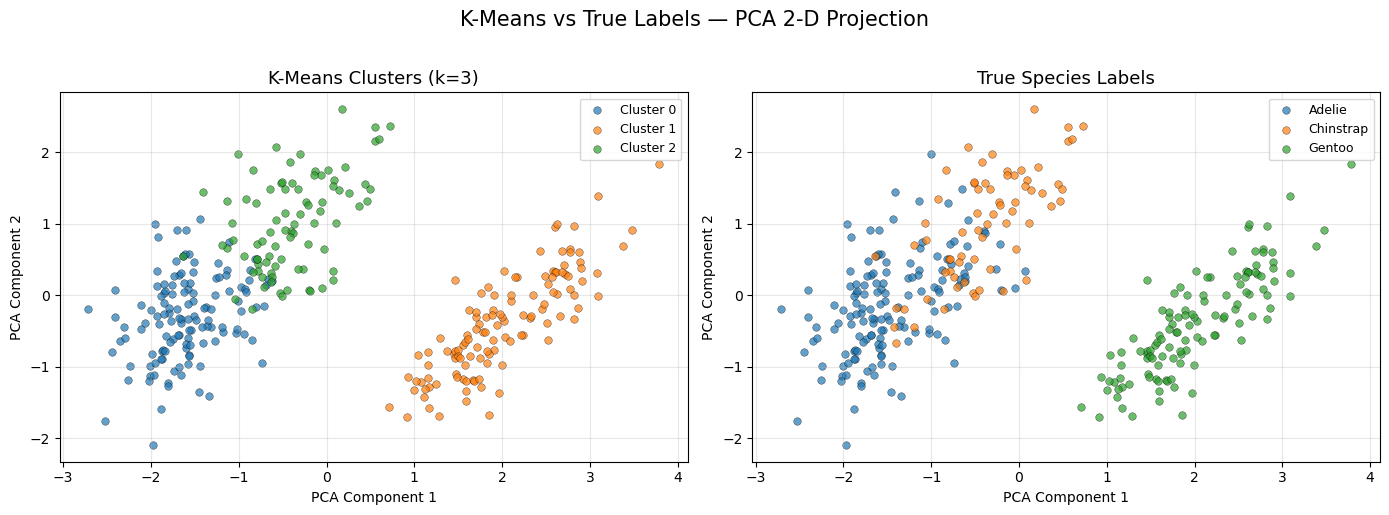

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette_species = {'Adelie': '#1f77b4', 'Chinstrap': '#ff7f0e', 'Gentoo': '#2ca02c'}

for cl in np.unique(km_labels):
    mask = km_labels == cl
    axes[0].scatter(X_pca_pen[mask, 0], X_pca_pen[mask, 1],
                    s=30, alpha=0.7, edgecolors='k', linewidths=0.3,
                    label=f'Cluster {cl}')
axes[0].set_title("K-Means Clusters (k=3)", fontsize=13)
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)


for sp, color in palette_species.items():
    mask = species == sp
    axes[1].scatter(X_pca_pen[mask, 0], X_pca_pen[mask, 1],
                    c=color, label=sp, s=30, alpha=0.7,
                    edgecolors='k', linewidths=0.3)
axes[1].set_title("True Species Labels", fontsize=13)
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("K-Means vs True Labels — PCA 2-D Projection", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Did Unsupervised Learning "Rediscover" the Species?

### Overall Result

Yes — to a large extent. The ARI and NMI scores are both well above zero, indicating that K-Means recovered much of the true species structure from the raw measurements alone, without ever seeing the labels.

### Where It Succeeded

**Gentoo penguins** are the easiest win. They are physically distinct (larger body mass, longer flippers) and form a well-separated cluster in every projection. K-Means assigns them almost perfectly to a single cluster. This is visible in the PCA plot: the Gentoo cloud sits clearly apart from the other two species.

### Where It Struggled

**Adelie and Chinstrap** overlap considerably in the four numeric features. Their bill depths, flipper lengths, and body masses are similar enough that K-Means cannot draw a clean boundary between them. The PCA plot shows the two groups blending in the overlap zone, and some Adelie points end up in the Chinstrap cluster and vice versa. This boundary confusion is the primary source of error and is what prevents ARI/NMI from reaching 1.0.

### What This Tells Us About Unsupervised Methods as a Substitute for Labeled Data

- **When clusters are well-separated in feature space**, unsupervised methods can reliably recover the true grouping — labels are unnecessary.
- **When classes overlap** in the available features, unsupervised clustering will merge or split groups in ways that diverge from the true labels. Additional features (e.g., island, sex, beak shape details) or domain knowledge would be needed to resolve the ambiguity.
- **Unsupervised learning is most valuable as a first pass** — it can reveal natural groupings, validate whether labeled categories correspond to real structure, and guide feature engineering. However, for fine-grained distinctions between similar classes, supervised methods with labeled data remain superior.